In [26]:
import numpy as np

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import TimeDistributed

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [27]:

# Dataset
# We have 8 sentences in English and their corresponding translations in German.

english_sentences = [
   "hello",
    "good morning",
    "good evening",
    "i am hungry",
    "i need water",
    "i love you",
    "the cat is sleeping",
    "learning ai is fun"
]

german_sentences = [
   "hallo",
    "guten morgen",
    "guten abend",
    "ich habe hunger",
    "ich brauche wasser",
    "ich liebe dich",
    "die katze schlaeft",
    "ki lernen macht spass"
]


In [28]:

# 2. Tokenization
# We will use Keras's Tokenizer to convert the sentences into sequences of integers.

eng_tokenizer = Tokenizer()
ger_tokenizer = Tokenizer()

# Fit the tokenizers on the sentences and convert the sentences to sequences of integers.
eng_tokenizer.fit_on_texts(english_sentences)
ger_tokenizer.fit_on_texts(german_sentences)

# Convert the sentences to sequences of integers.
X = eng_tokenizer.texts_to_sequences(english_sentences)
y = ger_tokenizer.texts_to_sequences(german_sentences)

In [29]:

# 3. Padding

# We need to pad the sequences so that they all have the same length. We will use Keras's pad_sequences function for this.
max_len = max(
    max(len(seq) for seq in X),
    max(len(seq) for seq in y)
)

X = pad_sequences(
    X,
    maxlen=max_len,
    padding="post"
)

y = pad_sequences(
    y,
    maxlen=max_len,
    padding="post"
)

In [30]:


# 4. Reshape output
# The output needs to be reshaped to be 3D for the TimeDistributed layer. The shape should be (num_samples, max_len, 1).
# This is required because the TimeDistributed layer expects the output to be 3D, where the 
# last dimension is the number of classes (in this case, 1 for each word in the sequence).

# Required for TimeDistributed

y = np.expand_dims(y, axis=-1)

In [31]:

# 5. Vocabulary sizes

eng_vocab_size = len(eng_tokenizer.word_index) + 1
ger_vocab_size = len(ger_tokenizer.word_index) + 1
print(f"English Vocabulary Size: {eng_vocab_size}")
print(f"German Vocabulary Size: {ger_vocab_size}")

English Vocabulary Size: 19
German Vocabulary Size: 19


In [32]:

# 6. Build model
model = Sequential()

# Embedding layer
model.add(Embedding( input_dim=eng_vocab_size, output_dim=8,input_length=max_len))

In [33]:

# RNN layer
# IMPORTANT:
# return_sequences=True

model.add(
    SimpleRNN(16,return_sequences=True)
    )

# Output layer
# Predicts one German word at each timestep

model.add(
    TimeDistributed(Dense(ger_vocab_size, activation="softmax"))
    )

In [34]:

# 7. Compile model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



In [35]:

# 8. Model summary
model.summary()


# 9. Train model
history = model.fit(
    X,
    y,
    epochs=250,
    batch_size=2
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1875 - loss: 2.9357      
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2812 - loss: 2.9195
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4062 - loss: 2.9041
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5312 - loss: 2.8860
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5312 - loss: 2.8684
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5312 - loss: 2.8488
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5312 - loss: 2.8283
Epoch 8/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 2.8022
Epoch 9/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 2.7737
Epoch 10/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 2.7452
Epoch 11/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4688 - loss: 2.7101
Epoch 12/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4375 - loss: 2.

In [36]:
print("\nTranslations:\n")

for sentence in english_sentences:

    # Convert sentence into numbers
    sequence = eng_tokenizer.texts_to_sequences([sentence])

    # Padding
    sequence = pad_sequences(
        sequence,
        maxlen=max_len,
        padding="post"
    )

    # Predict
    prediction = model.predict(sequence)

    # Get highest probability ids
    predicted_ids = np.argmax(
        prediction,
        axis=-1
    )

    # Convert ids back to words
    translated_sentence = ger_tokenizer.sequences_to_texts(
        predicted_ids
    )

    # Print result
    print(sentence, "→", translated_sentence[0])


Translations:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
hello → hallo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
good morning → guten morgen
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
good evening → guten abend
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
i am hungry → ich habe hunger
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
i need water → ich brauche wasser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
i love you → ich liebe dich
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
the cat is sleeping → die katze schlaeft
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
learning ai is fun → ki lernen macht spass


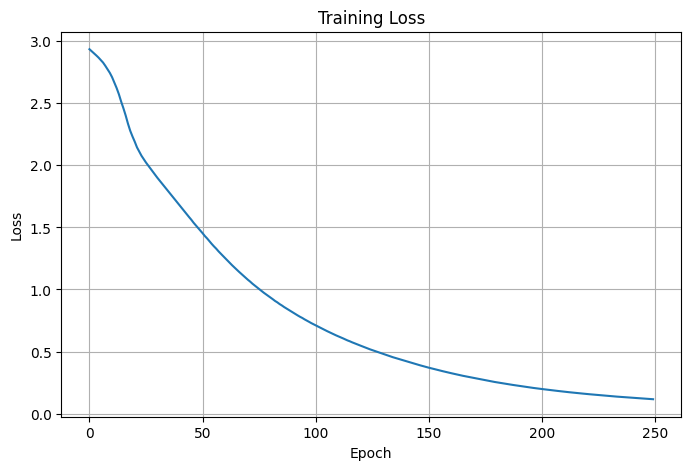

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()